Experiment 10: Unsupervised Generative Models

Aim: To implement an Unsupervised Generative Model using Autoencoder in TensorFlow and Keras.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Reshape)        │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6727 - loss: 0.5411 - val_accuracy: 0.7987 - val_loss: 0.3092
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7871 - loss: 0.2889 - val_accuracy: 0.8033 - val_loss: 0.2642
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7930 - loss: 0.2603 - val_accuracy: 0.8010 - val_loss: 0.2464
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7918 - loss: 0.2408 - val_accuracy: 0.7994 - val_loss: 0.2284
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7914 - loss: 0.2214 - val_accuracy: 0.8010 - val_loss: 0.2132

Test Loss     : 0.2132
Test Accuracy : 0.8010


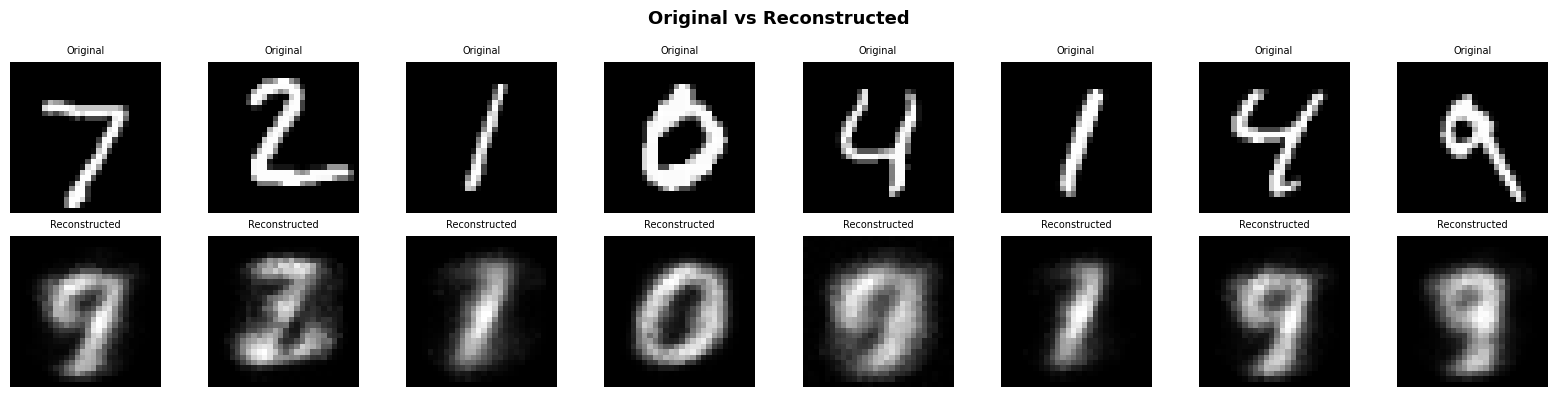

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape      # Condensed imports

# Load MNIST Dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize Dataset
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Reshape Dataset
X_train = X_train.reshape(-1, 28, 28, 1)               # Dynamic reshape
X_test  = X_test.reshape(-1, 28, 28, 1)

print(f"Training Shape : {X_train.shape}")
print(f"Testing Shape  : {X_test.shape}")

# Use subset for faster training
X_train_fast = X_train[:12000]                          # 12k instead of 60k
X_test_fast  = X_test[:2000]                            # 2k instead of 10k

# --- Encoder ---
encoder_input = Input(shape=(28, 28, 1), name='encoder_input')

x       = Flatten()(encoder_input)
x       = Dense(64, activation='relu', name='encoder_dense_1')(x)      # Reduced from 128
encoded = Dense(32, activation='relu', name='encoder_dense_2')(x)      # Reduced from 64

# --- Decoder ---
x       = Dense(64,      activation='relu',    name='decoder_dense_1')(encoded)  # Reduced from 128
x       = Dense(28 * 28, activation='sigmoid', name='decoder_dense_2')(x)
decoded = Reshape((28, 28, 1), name='decoder_output')(x)

# Autoencoder Model
autoencoder = Model(
    inputs=encoder_input,
    outputs=decoded
)

# Model Summary
autoencoder.summary()

# Compile Model
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = autoencoder.fit(
    X_train_fast,
    X_train_fast,
    epochs=5,                                           # Reduced from 10
    batch_size=512,                                     # Increased from 256
    validation_data=(X_test_fast, X_test_fast),
    verbose=1
)

# Evaluate Model
loss, accuracy = autoencoder.evaluate(X_test_fast, X_test_fast, verbose=0)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

# Generate Reconstructed Images
decoded_images = autoencoder.predict(X_test[:8], verbose=0)  # Show 8 instead of 5

# Display Original and Reconstructed Images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Original vs Reconstructed', fontsize=13, fontweight='bold')

for i in range(8):
    # Original
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title('Original', fontsize=7)
    axes[0, i].axis('off')

    # Reconstructed
    axes[1, i].imshow(decoded_images[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Reconstructed', fontsize=7)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Conclusion: Successfully implemented an unsupervised generative model using Autoencoder architecture in TensorFlow and Keras for image reconstruction.